Polynomial (deg 5) final MSE = 0.19553
MLP ReLU (32-32)   final MSE = 0.19051


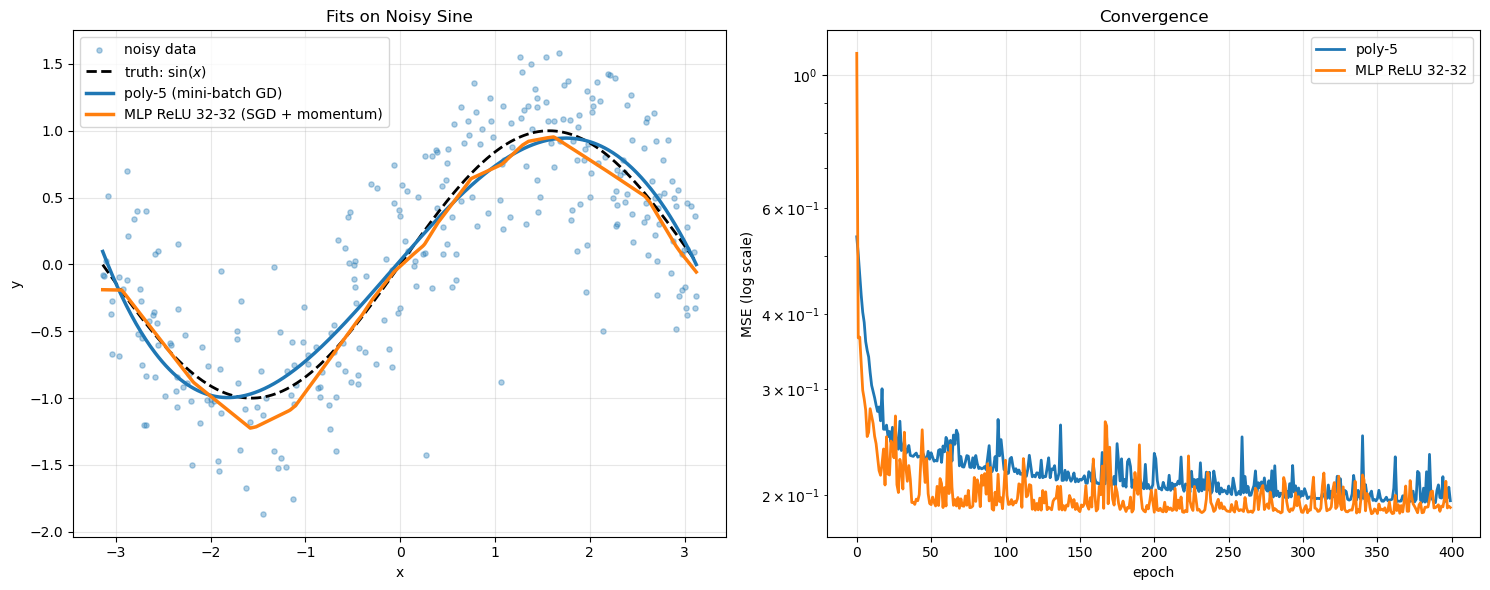

In [3]:
# =============================================================================
# NOISY SINE WAVE — POLYNOMIAL REGRESSION vs. MLP WITH ReLU
# =============================================================================
#
# Math reference
# --------------
#   Data:      y_i = sin(x_i) + eps_i,   eps_i ~ N(0, sigma^2),   x_i in [-pi, pi]
#
#   Polynomial regression (degree d):
#       y_hat(x) = sum_{k=0}^{d} w_k * x^k
#       J(w)     = (1/N) * sum_i ( y_hat(x_i) - y_i )^2
#       dJ/dw_j  = (2/N) * sum_i ( y_hat(x_i) - y_i ) * x_i^j
#
#   MLP with ReLU:
#       h^(l) = ReLU( W_l h^(l-1) + b_l ),  l = 1..L
#       y_hat = W_(L+1) h^(L) + b_(L+1)
#       ReLU(z) = max(0, z)
#       J(Theta) = (1/N) * sum_i ( y_hat_i - y_i )^2
#
#   Backprop uses the chain rule; the ReLU derivative is 1[z > 0].
#
#   Optimizer: SGD with momentum and gradient clipping:
#       v <- mu * v - alpha * clip(grad)
#       theta <- theta + v
#
# Numeric stability notes
# -----------------------
#   * Always standardize x before building the Vandermonde matrix.
#   * Use a modest learning rate for high-degree polynomial fits.
#   * Clip gradients to avoid runaway updates.
#   * Add a tiny L2 (ridge) penalty to keep coefficients bounded.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


# =============================================================================
# 1. DATA AND HELPERS
# =============================================================================
def generate_data(N=300, sigma=0.25, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.uniform(-np.pi, np.pi, size=N)
    y = np.sin(X) + rng.normal(0, sigma, size=N)
    return X, y


def standardize(x):
    mu, sd = x.mean(), x.std()
    return (x - mu) / sd, mu, sd


def vandermonde(x, degree):
    return np.vstack([x ** k for k in range(degree + 1)]).T


def clip_grad(g, max_norm):
    """Global-norm gradient clipping."""
    n = np.linalg.norm(g)
    if n > max_norm:
        g = g * (max_norm / (n + 1e-12))
    return g


# =============================================================================
# 2. POLYNOMIAL REGRESSION — MINI-BATCH GD WITH CLIPPING + RIDGE
# =============================================================================
def fit_polynomial(X, y, degree=5, lr=0.01, epochs=400, batch_size=32,
                   lam=1e-4, max_norm=5.0):
    """Return learned weights and loss history.

    Uses a small ridge penalty (lam) and gradient clipping (max_norm)
    to keep the fit numerically stable.
    """
    Xmat = vandermonde(X, degree)      # [N, degree+1]
    N, D = Xmat.shape
    w = np.zeros(D)
    losses = []
    rng = np.random.default_rng(1)

    for _ in range(epochs):
        idx = rng.permutation(N)
        for s in range(0, N, batch_size):
            b = idx[s:s + batch_size]
            Xb, yb = Xmat[b], y[b]
            err = Xb @ w - yb
            grad = (2.0 / len(b)) * (Xb.T @ err) + 2.0 * lam * w
            grad = clip_grad(grad, max_norm)
            w -= lr * grad
        losses.append(float(np.mean((Xmat @ w - y) ** 2)))
    return w, losses


# =============================================================================
# 3. MLP WITH ReLU — MINI-BATCH SGD + MOMENTUM
# =============================================================================
class MLP:
    """Fully-connected MLP with ReLU hidden layers and a linear output.

    Architecture: D -> h1 -> h2 -> ... -> 1
    Loss: MSE = (1/m) * sum_i (y_hat_i - y_i)^2
    Optimizer: SGD with momentum (heavy-ball).
    """

    def __init__(self, layer_sizes, seed=0):
        rng = np.random.default_rng(seed)
        self.W, self.b = [], []
        for i in range(len(layer_sizes) - 1):
            fan_in, fan_out = layer_sizes[i], layer_sizes[i + 1]
            scale = np.sqrt(2.0 / fan_in)         # He init for ReLU
            self.W.append(rng.normal(0, scale, size=(fan_out, fan_in)))
            self.b.append(np.zeros(fan_out))

    def forward(self, X):
        cache = {"A": [X], "Z": []}
        A = X
        for i in range(len(self.W) - 1):
            Z = A @ self.W[i].T + self.b[i]
            A = np.maximum(0.0, Z)                # ReLU
            cache["Z"].append(Z)
            cache["A"].append(A)
        Z_out = A @ self.W[-1].T + self.b[-1]
        cache["Z"].append(Z_out)
        cache["A"].append(Z_out)
        return Z_out, cache

    def backward(self, cache, y):
        m = y.shape[0]
        A, Z = cache["A"], cache["Z"]
        n_layers = len(self.W)

        dZ = (2.0 / m) * (A[-1] - y.reshape(-1, 1))

        dW = [None] * n_layers
        db = [None] * n_layers

        for i in reversed(range(n_layers)):
            dW[i] = dZ.T @ A[i]
            db[i] = dZ.sum(axis=0)
            if i > 0:
                dA = dZ @ self.W[i]
                dZ = dA * (Z[i - 1] > 0)          # ReLU derivative
        return dW, db

    def step(self, dW, db, lr, momentum, velocity, max_norm=5.0):
        for i in range(len(self.W)):
            gW = clip_grad(dW[i], max_norm)
            gb = clip_grad(db[i], max_norm)
            velocity["W"][i] = momentum * velocity["W"][i] - lr * gW
            velocity["b"][i] = momentum * velocity["b"][i] - lr * gb
            self.W[i] += velocity["W"][i]
            self.b[i] += velocity["b"][i]


def fit_mlp(X, y, hidden=(32, 32), lr=0.02, epochs=400,
            batch_size=32, momentum=0.9, seed=0):
    X_col = X.reshape(-1, 1)
    y_col = y.reshape(-1, 1)

    sizes = [1, *hidden, 1]
    net = MLP(sizes, seed=seed)

    velocity = {
        "W": [np.zeros_like(W) for W in net.W],
        "b": [np.zeros_like(b) for b in net.b],
    }

    N = X_col.shape[0]
    losses = []
    rng = np.random.default_rng(seed + 1)

    for _ in range(epochs):
        idx = rng.permutation(N)
        for s in range(0, N, batch_size):
            b = idx[s:s + batch_size]
            Xb, yb = X_col[b], y_col[b]
            _, cache = net.forward(Xb)
            dW, db = net.backward(cache, yb)
            net.step(dW, db, lr, momentum, velocity)
        y_hat, _ = net.forward(X_col)
        losses.append(float(np.mean((y_hat - y_col) ** 2)))
    return net, losses


# =============================================================================
# 4. RUN THE EXPERIMENT
# =============================================================================
X, y = generate_data(N=300, sigma=0.45, seed=0)
X_std, mu, sd = standardize(X)

# ---- Polynomial regression (degree 5, small lr, ridge, clip) ----
w_poly, losses_poly = fit_polynomial(
    X_std, y,
    degree=5,
    lr=0.01,           # smaller lr than before
    epochs=400,
    batch_size=32,
    lam=1e-4,          # tiny ridge penalty
    max_norm=5.0,      # gradient clipping
)

# ---- MLP with ReLU ----
net_mlp, losses_mlp = fit_mlp(
    X_std, y,
    hidden=(32, 32),
    lr=0.02,
    epochs=400,
    batch_size=32,
    momentum=0.9,
    seed=0,
)

print(f"Polynomial (deg 5) final MSE = {losses_poly[-1]:.5f}")
print(f"MLP ReLU (32-32)   final MSE = {losses_mlp[-1]:.5f}")


# =============================================================================
# 5. EVALUATE ON A DENSE GRID AND PLOT
# =============================================================================
x_grid = np.linspace(X.min(), X.max(), 500)
x_grid_std = (x_grid - mu) / sd
Xs_true = np.sin(x_grid)

Xg_poly = vandermonde(x_grid_std, 5)
y_poly = Xg_poly @ w_poly

y_mlp, _ = net_mlp.forward(x_grid_std.reshape(-1, 1))
y_mlp = y_mlp.ravel()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
ax.scatter(X, y, s=14, alpha=0.35, label="noisy data")
ax.plot(x_grid, Xs_true, "k--", lw=2, label=r"truth: $\sin(x)$")
ax.plot(x_grid, y_poly, lw=2.5, label="poly-5 (mini-batch GD)")
ax.plot(x_grid, y_mlp, lw=2.5, label="MLP ReLU 32-32 (SGD + momentum)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Fits on Noisy Sine")
ax.legend()

ax = axes[1]
ax.plot(losses_poly, lw=2, label="poly-5")
ax.plot(losses_mlp, lw=2, label="MLP ReLU 32-32")
ax.set_yscale("log")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE (log scale)")
ax.set_title("Convergence")
ax.legend()

plt.tight_layout()
plt.savefig("mlp_sine_results.png", dpi=130)
plt.show()